In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import IsolationForest, RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

print("Libraries loaded successfully ")

Libraries loaded successfully 


In [4]:
data = {
    "Date": pd.date_range(start="2026-01-01", periods=120, freq="D"),
    "Category": np.random.choice(
        ["Food", "Travel", "Shopping", "Bills", "Entertainment"],
        120
    ),
    "Amount": np.random.randint(100, 5000, 120)
}

df = pd.DataFrame(data)

# Add a few unusual transactions
df.loc[10, "Amount"] = 18000
df.loc[55, "Amount"] = 22000
df.loc[90, "Amount"] = 25000

df.head()

,Date,Category,Amount
0,2026-01-01,Entertainment,2720
1,2026-01-02,Food,4494
2,2026-01-03,Entertainment,4209
3,2026-01-04,Shopping,1014
4,2026-01-05,Bills,3218


In [6]:
print("Total Spending:", df["Amount"].sum())
print("\nCategory-wise Spending:")
print(df.groupby("Category")["Amount"].sum().sort_values(ascending=False))

Total Spending: 353021

Category-wise Spending:
Category
Bills            138959
Entertainment     59457
Food              55966
Travel            54185
Shopping          44454
Name: Amount, dtype: int64


In [8]:
# AI-based anomaly detection

model = IsolationForest(
    contamination=0.05,
    random_state=42
)

df["Anomaly"] = model.fit_predict(df[["Amount"]])

# Convert results into readable labels
df["Transaction_Status"] = df["Anomaly"].map({
    1: "Normal",
    -1: "Suspicious"
})

print("Transaction Analysis Completed ")
print("\nSuspicious Transactions:")

df[df["Transaction_Status"] == "Suspicious"]

Transaction Analysis Completed 

Suspicious Transactions:


,Date,Category,Amount,Anomaly,Transaction_Status
10,2026-01-11,Bills,18000,-1,Suspicious
26,2026-01-27,Travel,4970,-1,Suspicious
36,2026-02-06,Entertainment,188,-1,Suspicious
45,2026-02-15,Shopping,145,-1,Suspicious
55,2026-02-25,Bills,22000,-1,Suspicious
90,2026-04-01,Bills,25000,-1,Suspicious


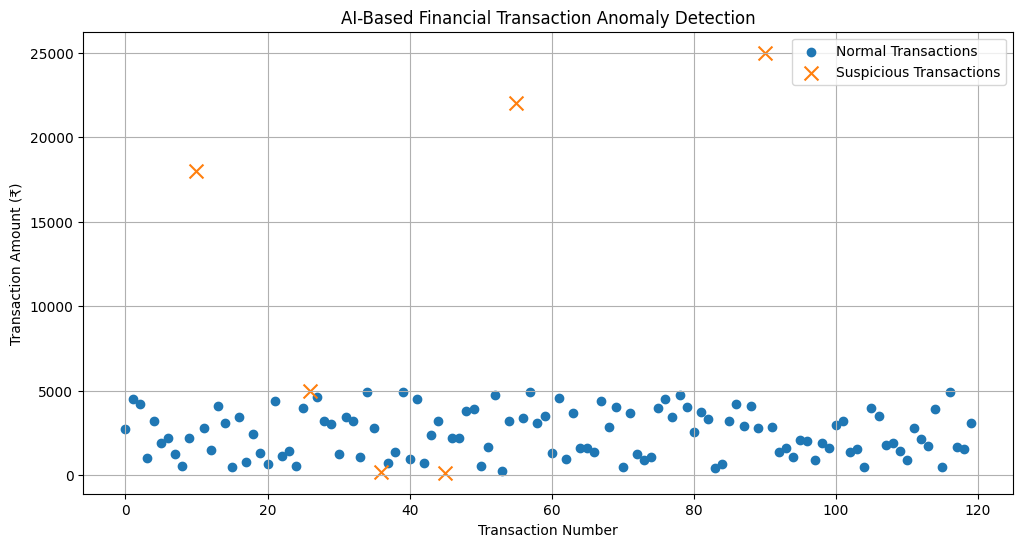

In [9]:
plt.figure(figsize=(12, 6))

normal = df[df["Transaction_Status"] == "Normal"]
suspicious = df[df["Transaction_Status"] == "Suspicious"]

plt.scatter(
    normal.index,
    normal["Amount"],
    label="Normal Transactions"
)

plt.scatter(
    suspicious.index,
    suspicious["Amount"],
    label="Suspicious Transactions",
    marker="x",
    s=100
)

plt.title("AI-Based Financial Transaction Anomaly Detection")
plt.xlabel("Transaction Number")
plt.ylabel("Transaction Amount (₹)")
plt.legend()
plt.grid(True)

plt.show()

In [10]:
# Prepare data for expense prediction

df["Day_Number"] = np.arange(len(df))

X = df[["Day_Number"]]
y = df["Amount"]

# Split data into training and testing data
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Train the Random Forest Regression model
prediction_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

prediction_model.fit(X_train, y_train)

# Make predictions
predictions = prediction_model.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, predictions)

print("AI Expense Prediction Model Completed ✅")
print("Mean Absolute Error:", round(mae, 2))

AI Expense Prediction Model Completed ✅
Mean Absolute Error: 3830.79


In [12]:
# Prepare data for expense prediction

df["Day_Number"] = np.arange(len(df))

X = df[["Day_Number"]]
y = df["Amount"]

# Split data into training and testing data
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Train the Random Forest Regression model
prediction_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

prediction_model.fit(X_train, y_train)

# Make predictions
predictions = prediction_model.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, predictions)

print("AI Expense Prediction Model Completed ")
print("Mean Absolute Error:", round(mae, 2))

AI Expense Prediction Model Completed 
Mean Absolute Error: 3830.79


In [13]:
# Predict future expenses for the next 30 days

future_days = pd.DataFrame({
    "Day_Number": np.arange(len(df), len(df) + 30)
})

future_predictions = prediction_model.predict(future_days)

future_df = pd.DataFrame({
    "Future_Day": np.arange(1, 31),
    "Predicted_Expense": np.round(future_predictions, 2)
})

print("Predicted Expenses for the Next 30 Days")
display(future_df.head(10))

Predicted Expenses for the Next 30 Days


,Future_Day,Predicted_Expense
0,1,2697.88
1,2,2697.88
2,3,2697.88
3,4,2697.88
4,5,2697.88
5,6,2697.88
6,7,2697.88
7,8,2697.88
8,9,2697.88
9,10,2697.88


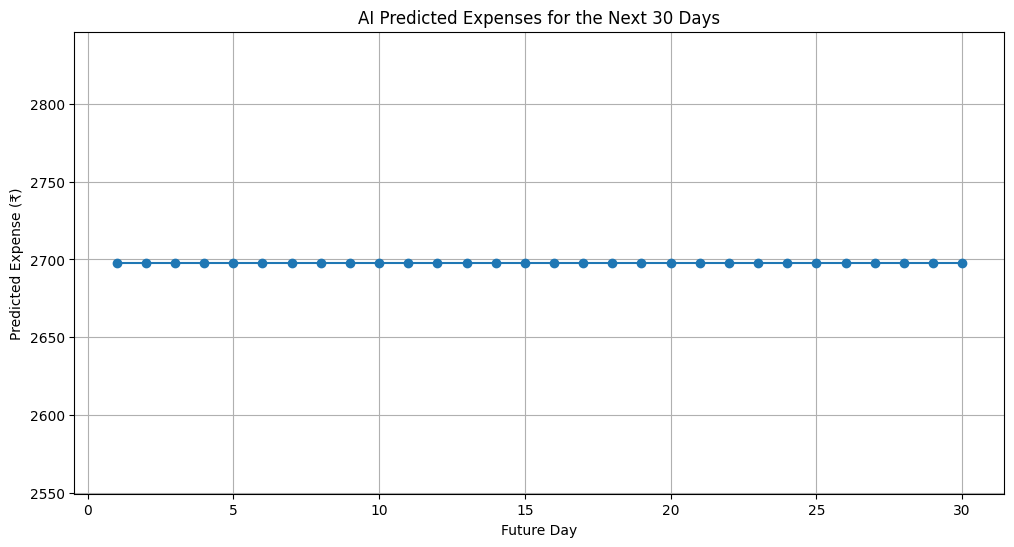

In [14]:
plt.figure(figsize=(12, 6))

plt.plot(
    future_df["Future_Day"],
    future_df["Predicted_Expense"],
    marker="o"
)

plt.title("AI Predicted Expenses for the Next 30 Days")
plt.xlabel("Future Day")
plt.ylabel("Predicted Expense (₹)")
plt.grid(True)

plt.show()

In [15]:
# Smart Budget Recommendation Engine

total_spending = df["Amount"].sum()

# Example budget for the analysed period
budget = 400000

remaining_budget = budget - total_spending
budget_usage = (total_spending / budget) * 100

print(" SMART FINANCE SUMMARY")
print("-" * 45)
print(f"Total Spending: ₹{total_spending:,.2f}")
print(f"Budget: ₹{budget:,.2f}")
print(f"Remaining Budget: ₹{remaining_budget:,.2f}")
print(f"Budget Used: {budget_usage:.2f}%")

if remaining_budget < 0:
    print("\n ALERT: Budget exceeded!")
elif budget_usage >= 80:
    print("\n WARNING: More than 80% of the budget has been used.")
else:
    print("\n Budget Status: Spending is currently under control.")

 SMART FINANCE SUMMARY
---------------------------------------------
Total Spending: ₹353,021.00
Budget: ₹400,000.00
Remaining Budget: ₹46,979.00
Budget Used: 88.26%



In [16]:
# Personalized Financial Recommendations

category_spending = (
    df.groupby("Category")["Amount"]
    .sum()
    .sort_values(ascending=False)
)

highest_category = category_spending.index[0]
highest_amount = category_spending.iloc[0]

suspicious_count = (
    df["Transaction_Status"] == "Suspicious"
).sum()

print(" SPENDWISE AI RECOMMENDATIONS")
print("-" * 45)

print(f" Highest spending category: {highest_category}")
print(f" Amount spent: ₹{highest_amount:,.2f}")

print(
    f"\n Recommendation: Try reducing {highest_category} "
    f"spending by 10–15% to improve your savings."
)

if suspicious_count > 0:
    print(
        f"\n Security Alert: {suspicious_count} suspicious "
        "transactions were detected. Please review them."
    )

print(
    "\n Forecast Insight: Monitor predicted expenses "
    "before making major purchases."
)

print("\n AI Financial Analysis Completed!")

 SPENDWISE AI RECOMMENDATIONS
---------------------------------------------
 Highest spending category: Bills
 Amount spent: ₹138,959.00

 Recommendation: Try reducing Bills spending by 10–15% to improve your savings.

 Security Alert: 6 suspicious transactions were detected. Please review them.

 Forecast Insight: Monitor predicted expenses before making major purchases.

 AI Financial Analysis Completed!


In [17]:
# SPENDWISE AI - FINANCE CONTROLLER DASHBOARD

print("=" * 55)
print("         SPENDWISE AI FINANCE CONTROLLER")
print("=" * 55)

print("\n FINANCIAL OVERVIEW")
print(f" Total Spending: ₹{total_spending:,.2f}")
print(f" Budget: ₹{budget:,.2f}")
print(f" Remaining Budget: ₹{remaining_budget:,.2f}")
print(f" Budget Used: {budget_usage:.2f}%")

print("\n AI RISK ANALYSIS")
print(f" Suspicious Transactions Detected: {suspicious_count}")

print("\n SPENDING ANALYSIS")
print(f" Highest Spending Category: {highest_category}")
print(f" Highest Category Amount: ₹{highest_amount:,.2f}")

print("\n AI FORECAST")
print(f" Average Predicted Daily Expense: ₹{future_df['Predicted_Expense'].mean():,.2f}")

print("\n AI STATUS")
print(" Financial analysis completed successfully")
print(" AI-powered insights generated")
print("=" * 55)

         SPENDWISE AI FINANCE CONTROLLER

 FINANCIAL OVERVIEW
 Total Spending: ₹353,021.00
 Budget: ₹400,000.00
 Remaining Budget: ₹46,979.00
 Budget Used: 88.26%

 AI RISK ANALYSIS
 Suspicious Transactions Detected: 6

 SPENDING ANALYSIS
 Highest Spending Category: Bills
 Highest Category Amount: ₹138,959.00

 AI FORECAST
 Average Predicted Daily Expense: ₹2,697.88

 AI STATUS
 Financial analysis completed successfully
 AI-powered insights generated


In [19]:
# SPENDWISE AI - FINANCIAL HEALTH SCORE

# Start with a perfect score
health_score = 100

# 1. Budget usage impact
if budget_usage >= 90:
    health_score -= 30
elif budget_usage >= 80:
    health_score -= 20
elif budget_usage >= 70:
    health_score -= 10

# 2. Suspicious transaction impact
health_score -= suspicious_count * 3

# 3. Spending concentration impact
highest_category_percentage = (
    highest_amount / total_spending
) * 100

if highest_category_percentage >= 40:
    health_score -= 15
elif highest_category_percentage >= 30:
    health_score -= 10

# Keep score between 0 and 100
health_score = max(0, min(100, health_score))

# Financial status
if health_score >= 80:
    health_status = "Excellent"
elif health_score >= 60:
    health_status = "Good - Needs Attention"
elif health_score >= 40:
    health_status = "Moderate Risk"
else:
    health_status = "High Financial Risk"

print("=" * 50)
print(" SPENDWISE AI FINANCIAL HEALTH REPORT")
print("=" * 50)

print(f"\n Financial Health Score: {health_score}/100")
print(f" Financial Status: {health_status}")

print(f"\n Budget Usage: {budget_usage:.2f}%")
print(f" Suspicious Transactions: {suspicious_count}")
print(f" Highest Category Concentration: "
      f"{highest_category_percentage:.2f}%")

print("\n AI Recommendation:")

if health_score < 60:
    print("Reduce unnecessary expenses and review suspicious transactions.")
elif health_score < 80:
    print("Your finances are stable, but spending should be monitored.")
else:
    print("Excellent financial discipline! Continue maintaining your budget.")

print("\n Financial Health Analysis Completed!")
print("=" * 50)

 SPENDWISE AI FINANCIAL HEALTH REPORT

 Financial Health Score: 52/100
 Financial Status: Moderate Risk

 Budget Usage: 88.26%
 Suspicious Transactions: 6
 Highest Category Concentration: 39.36%

 AI Recommendation:
Reduce unnecessary expenses and review suspicious transactions.

 Financial Health Analysis Completed!
